<a href="https://colab.research.google.com/github/csyh24096-ship-it/Experiment-of-deep-learning/blob/main/c5_4096.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.必要なライブラリをインポートする

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from torch.utils import data
import torchvision
from torchvision import datasets
from torchvision import transforms as T
from torchsummary import summary
import numpy as np
import pandas as pd
import matplotlib as mpl
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import time
import os
import math

#mean = [0.485,0.456,0.406]
#std = [0.229,0.224,0.225]
#print('pytorch',torch.__version__)
#print('torchvision', torchvision.__version__)

#2.ドライブをマウントする


In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


#3.実験用ディレクトリを構築する

#4.テスト用データセットのダウンロード及び確認


In [ ]:
import tensorflow_datasets as tfds
ds_test, ds_info = tfds.load(
    'rock_paper_scissors',
    split='test',
    shuffle_files=False,
    as_supervised=True,
    with_info=True,
)
display(ds_info)

tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir='/root/tensorflow_datasets/rock_paper_scissors/3.0.0',
    file_format=tfrecord,
    download_size=219.53 MiB,
    dataset_size=219.23 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=372, num_shards=1>,
        'train': <SplitInfo num_examples=2520, num_shards=2>,
    },
    citation="""@ONLINE {rps,
    author = "Laurence Moroney",
    title = "Rock, Paper, Scissors Dataset",
    month = "feb",
    year = "2019",
    url = "http://laurencemoroney.com/rock

#5.データセットクラス

In [ ]:
class CustomDataset(data.Dataset):
  def __init__(self, samples, transform=None):
    self.samples = samples
    self.transform = transform
    self.targets = samples[1]
  def __getitem__(self, index):
    x = self.samples[0][index]
    y = self.samples[1][index]
    if self.transform:
      x = self.transform(x)
    return x, y
  def __len__(self):
    return len(self.samples[0])

#6.テスト用データセット

In [ ]:
from PIL import Image
image_size = 64
transform_test = T.Compose([ # 変更可能
    T.Resize((image_size,image_size)),
    T.ToTensor(),
    #T.Normalize(mean=mean ,std=std)
    ])
x = [Image.fromarray(data[0].numpy()) for data in ds_test]
y = [data[1].numpy() for data in ds_test]
test_dataset = CustomDataset((x,y), transform_test)
print('test samples', len(test_dataset))

test samples 372


#7.学習用データ撮影


In [ ]:
#DO 写真撮る
#クリッピング

#8.自作データセットを読み込む

In [ ]:
dataset_dir = '/gdrive/MyDrive/C5_水12/images/train'
transform = T.Compose([
    #T.CenterCrop((300,300)), #中心部分を抽出
    T.Resize((image_size,image_size)),
    T.RandomRotation(degrees=5, fill=255), # 回転
    T.RandomPerspective(distortion_scale=0.1, fill = 255), # 歪み
    T.RandomHorizontalFlip(), # 左右反転
    T.ToTensor(),
    #T.Normalize(mean=mean, std=std)
    ])
train_dataset = datasets.ImageFolder(dataset_dir, transform)
print('train dataset', len(train_dataset))
train_samples = len(train_dataset)
print('train dataset class to idx:\n', train_dataset.class_to_idx, '\n')
classes = [key for key in train_dataset.class_to_idx]

train dataset 184
train dataset class to idx:
 {'0_グー': 0, '1_パー': 1, '2_チョキ': 2} 



#9.データセットの可視化

In [ ]:
train_df = pd.DataFrame(train_dataset.targets)
train_df = train_df.replace({0:classes[0], 1:classes[1], 2:classes[2]})
balance = train_df.value_counts()
display('train', balance)

test_df = pd.DataFrame(test_dataset.targets)
test_df = test_df.replace({0:classes[0], 1:classes[1], 2:classes[2]})
balance = test_df.value_counts()
display('test', balance)

'train'

,count
0,
2_チョキ,80
1_パー,53
0_グー,51


'test'

,count
0,
0_グー,124
1_パー,124
2_チョキ,124


#10.データローダの作成

In [ ]:
batch_size = 32
train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers = 2)
test_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers = 2)

#11.データの確認

train:


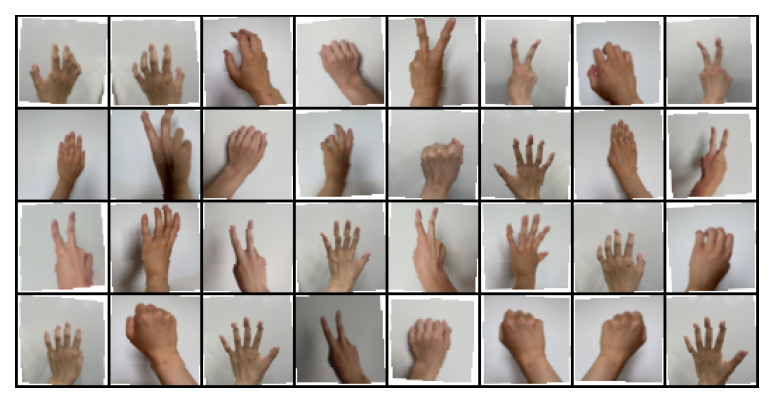

test:


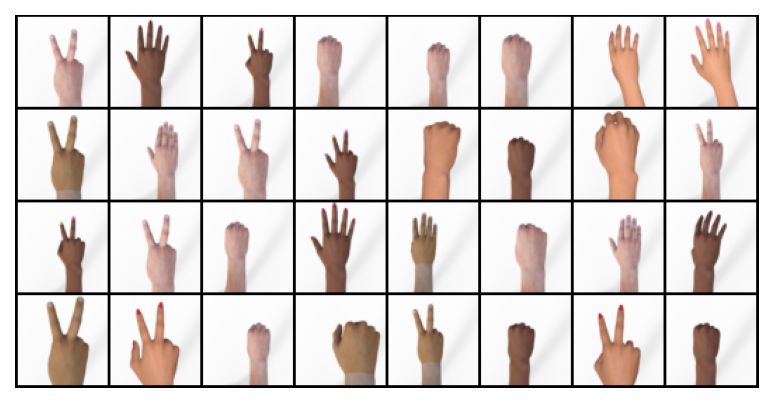

In [ ]:
def imshow(img):
  plt.axis('off')
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1,2,0)))
  plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
print("train:")
imshow(torchvision.utils.make_grid(images))

dataiter = iter(test_loader)
images, labels = next(dataiter)
print("test:")
imshow (torchvision.utils.make_grid(images))

#12.ロギング機能及び精度検証機能

In [ ]:
class Logger():
  def __init__(self,print_iteration, train_samples, batch_size):
    self.print_iteration = print_iteration
    self.iterations = math.ceil(train_samples / batch_size)
    self.log = {'loss': [],'acc': [], 'epochs':[]}
  def clear_run(self):
    self.run_loss = 0.0
    self.run_acc = 0.0
    self.run_count = 0
    self.s_time = time.time()
  def logging(self, outputs, loss, labels, epoch, i):
    b_size = outputs.size(0)
    self.run_loss += loss.item()
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum()
    accuracy = 100 * correct / b_size
    self.run_acc += accuracy.item()
    self.run_count += 1
    if i % self.print_iteration == 0 or i == self.iterations:
      e_time = (time.time() - self.s_time) / self.run_count
      progress = round(epoch + i / self.iterations, 2)
      self.log['loss'].append(self.run_loss / self.run_count)
      self.log['acc'].append(self.run_acc / self.run_count)
      self.log['epochs'].append(progress)
      print('[%5d, %9d] loss:%.3f, accuracy:%.2f%%, speed:%.3fs/iter' % (epoch, i, self.log['loss'][-1], self.log['acc'][-1], e_time))
      self.clear_run()
  def save(self, path):
    dict_ = dict(epochs = self.log['epochs'], loss = self.log['loss'],accuracy = self.log['acc'])
    df = pd.DataFrame(dict_)
    df.to_csv(path)

In [ ]:
class Evaluator():
  def __init__(self, dataloader, criterion, device):
    self.log = {'loss': [],'acc': [], 'epochs':[]}
    self.loader = dataloader
    self.device = device
    self.n_iters = len(self.loader)
    self.criterion = criterion
  def evaluation(self, model, epoch):
    model.eval()
    correct = 0
    val_loss = 0.0
    val_accuracy = 0.0
    test_samples = 0
    eval_start = time.time()
    for images, labels in self.loader:
      images = images.to(self.device)
      labels = labels.to(self.device)
      b_size = images.size(0)
      test_samples += b_size
      with torch.no_grad():
        outputs = model(images)
      loss = self.criterion(outputs, labels)
      val_loss += loss.item()
      _, predicted = torch.max(outputs.data, 1)
      correct += (predicted == labels).sum().item()
    eval_time = (time.time() - eval_start) / self.n_iters
    val_accuracy = 100 * correct / test_samples
    self.log['loss'].append(val_loss / self.n_iters)
    self.log['acc'].append(val_accuracy)
    self.log['epochs'].append(epoch)
    print('[%5d]test loss: %.3f, accuracy: %.2f%%, speed:%.3fs/iter' % (epoch, self.log['loss'][-1], self.log['acc'][-1], eval_time))
  def save(self, path):
    dict_ = dict(epochs = self.log['epochs'], loss = self.log['loss'],accuracy = self.log['acc'])
    df = pd.DataFrame(dict_)
    df.to_csv(path)

#13.モデル構築

In [ ]:
class MyCNN(nn.Module):
  def __init__(self):
    super(MyCNN, self).__init__()
    self.nets = nn.Sequential(
      nn.Conv2d(3,32, (3,3)),#3*64*64 -> 32*62*62
      nn.BatchNorm2d(32),
      nn.ReLU(),
      nn.MaxPool2d((2,2)), # 32*31*31
      nn.Conv2d(32,64, (3,3)), # 64*29*29
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.MaxPool2d((2,2)), # 64*14*14 ?
      nn.Conv2d(64,64, (3,3)), # 128*12*12
      nn.BatchNorm2d(64),
      nn.ReLU(),

      nn.Flatten(),
      nn.Linear(12*12*64, 12*64),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(12*64, 3*64),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(3*64,64),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(64,3)
    )
  def forward(self, x):
    y = self.nets(x)
    return y
  def predict(self, x):
    y = self.forword(x)
    return F.softmax(y, dim = 1)


#14.CNNのインスタンス生成、損失関数、最適化手法の設定

In [ ]:
def init_seed(seed=0):
  np.random.seed(seed) #npライブラリシード値の固定
  torch.manual_seed(seed) #Pytorchのシード値の固定
  torch.cuda.manual_seed(seed) #PytorchのGPU上のシード値の固定
  torch.backends.cudnn.deterministic = True #cuDNNのアルゴリズムのランダム性を無くす
seed = 3407 #seed値を3407に設定

learning_rate = 0.0005
init_seed(seed)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MyCNN().to(device)
summary(model, (3,image_size, image_size), device = device)
class_weights = torch.tensor([1,1.5,0.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr = learning_rate)
print('optimizer', optimizer)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 62, 62]             896
       BatchNorm2d-2           [-1, 32, 62, 62]              64
              ReLU-3           [-1, 32, 62, 62]               0
         MaxPool2d-4           [-1, 32, 31, 31]               0
            Conv2d-5           [-1, 64, 29, 29]          18,496
       BatchNorm2d-6           [-1, 64, 29, 29]             128
              ReLU-7           [-1, 64, 29, 29]               0
         MaxPool2d-8           [-1, 64, 14, 14]               0
            Conv2d-9           [-1, 64, 12, 12]          36,928
      BatchNorm2d-10           [-1, 64, 12, 12]             128
             ReLU-11           [-1, 64, 12, 12]               0
          Flatten-12                 [-1, 9216]               0
           Linear-13                  [-1, 768]       7,078,656
             ReLU-14                  [

#15.モデルの学習


In [ ]:
n_epoch = 10
print_iteration = 5#任意
logger = Logger(print_iteration, train_samples, batch_size)
eval = Evaluator(test_loader, criterion, device)
start = time.time()
for epoch in tqdm(range(n_epoch)):
  eval.evaluation(model, epoch)
  model.train()
  logger.clear_run()
  print_time = time.time()
  for i ,(images, labels) in enumerate(train_loader,0):
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    optimizer.zero_grad()
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    logger.logging(outputs, loss, labels, epoch, i+1)
  if epoch == 7:
    learning_rate = 0.0001

eval.evaluation(model, n_epoch)
elapsed_time = time.time() - start
print('training total', elapsed_time, 'sec.')

#データの記録
finalaccuracy = eval.log["acc"][-1] #accuracy
finalloss = eval.log["loss"][-1] # loss

  0%|          | 0/10 [00:00<?, ?it/s]

[    0]test loss: 1.108, accuracy: 33.33%, speed:0.059s/iter
[    0,         5] loss:1.089, accuracy:30.00%, speed:2.132s/iter
[    0,         6] loss:1.143, accuracy:20.83%, speed:0.012s/iter
[    1]test loss: 1.105, accuracy: 33.33%, speed:0.044s/iter
[    1,         5] loss:0.963, accuracy:42.50%, speed:2.496s/iter
[    1,         6] loss:0.958, accuracy:41.67%, speed:0.012s/iter
[    2]test loss: 1.117, accuracy: 33.33%, speed:0.036s/iter
[    2,         5] loss:0.844, accuracy:50.62%, speed:2.419s/iter
[    2,         6] loss:0.654, accuracy:54.17%, speed:0.264s/iter
[    3]test loss: 1.143, accuracy: 33.33%, speed:0.037s/iter
[    3,         5] loss:0.714, accuracy:63.75%, speed:2.564s/iter
[    3,         6] loss:0.774, accuracy:45.83%, speed:0.013s/iter
[    4]test loss: 1.310, accuracy: 33.33%, speed:0.035s/iter
[    4,         5] loss:0.601, accuracy:61.25%, speed:2.524s/iter
[    4,         6] loss:0.662, accuracy:54.17%, speed:0.011s/iter
[    5]test loss: 1.445, accuracy: 

#16.モデルの保存

In [ ]:
base_fol_prefix = '/gdrive/MyDrive/C5_水12/output' #MyDrive内のモデルを保存したいところにパスを指定する
folder_name = f'Acc{finalaccuracy:.2f}_Loss{finalloss:.3f}_Time{elapsed_time:.0f}s' #accuracy、loss、時間の名前を付けてフォルダを作成
base_fol = os.path.join(base_fol_prefix, folder_name) #↑で作成したフォルダ内にモデルを収納
os.makedirs(base_fol,exist_ok = True)
torch.save(model.state_dict(),os.path.join(base_fol,'mnist.pth'))
logger.save(os.path.join(base_fol,'train_loss_acc.csv'))
eval.save(os.path.join(base_fol,'test_loss_acc.csv'))
with open( os.path.join(base_fol,'architecture.txt'),mode = "w") as f:
  f.write('model\n')
  f.write(str(model))
  f.write('optimizer\n')
  f.write(str(optimizer))

#17.学習過程の可視化

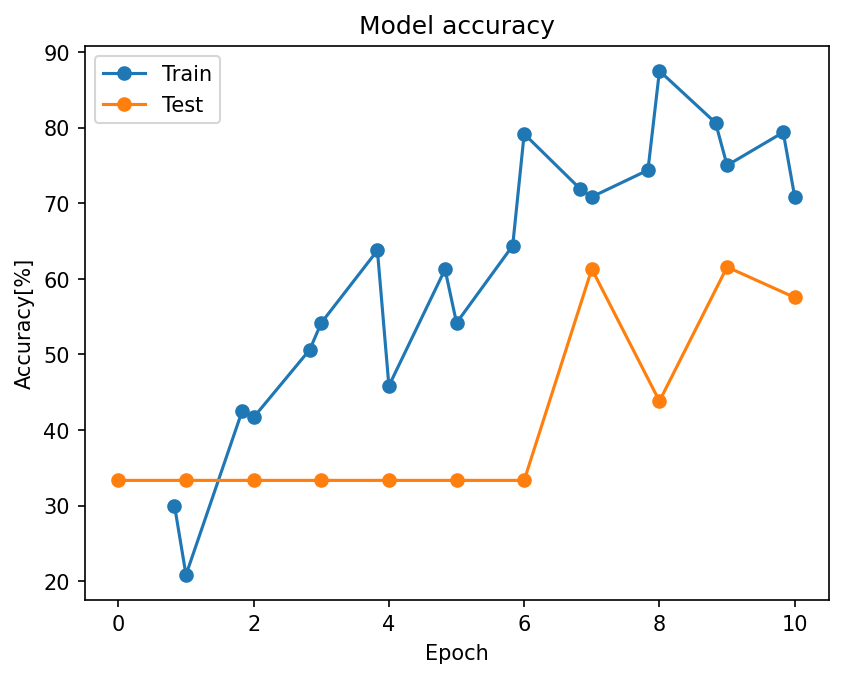

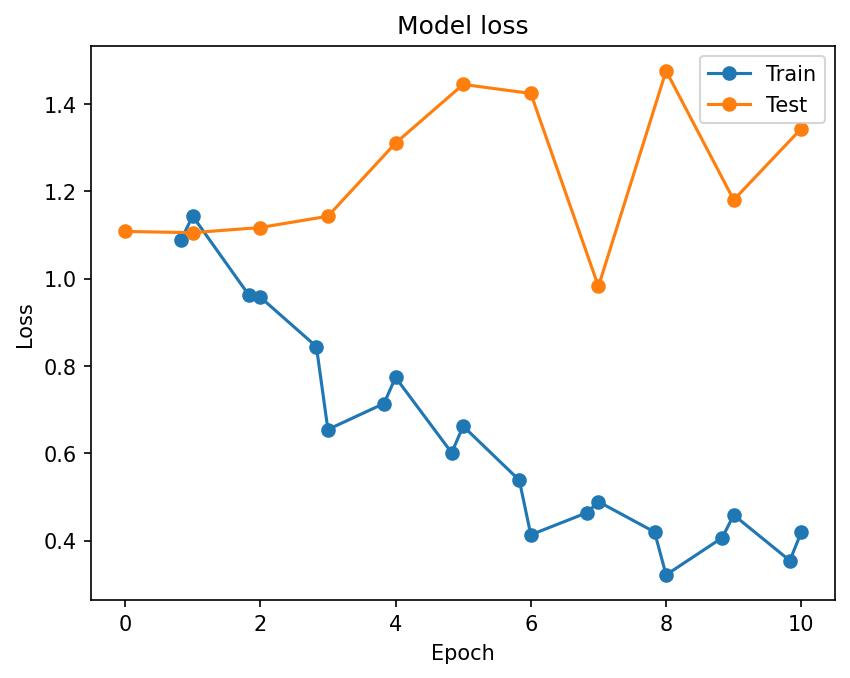

<Figure size 960x720 with 0 Axes>

In [ ]:
mpl.rcParams['figure.dpi'] = 150

plt.plot(logger.log['epochs'], logger.log['acc'], marker="o",linestyle='--')
plt.plot(eval.log['epochs'], eval.log['acc'], marker="o")
plt.title('Model accuracy')
plt.ylabel('Accuracy[%]')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()
plt.savefig(os.path.join(base_fol, 'accuracy_plot.png'))

plt.plot(logger.log['epochs'], logger.log['loss'], marker="o",linestyle='--')
plt.plot(eval.log['epochs'], eval.log['loss'], marker="o")
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()
plt.savefig(os.path.join(base_fol, 'loss_plot.png'))

#18.精度向上を検討する

In [1]:
#DO 考える

"""
transform
- T.RandomRotation(degrees=5, fill=255)  回転
- T.RandomPerspective(fill = 255) 歪み
- T.RandomHorizontalFlip() 左右反転
- T.ColorJitter([]) 明度などの変化
- ノイズ付与
"""

"""
model
- 層を増やす
- batchnorm バッチ正則化
- dropout()
"""

"""
最適化手法をAdam AdamWなどに変化させる
"""

"""
eval
- エポック数に応じてlrを変化させる
if epoch == 7
  learning_rate = 0.001
"""


'\neval\n- エポック数に応じてlrを変化させる\nif epoch == 7\n  learning_rate = 0.001\n'

#混同行列

In [ ]:
import torch
import numpy as np
import time
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix
def confusion(data_loader, model, classes, device):
  model.to(device)
  model.eval()
  correct = 0
  loss = 0.0
  accuracy = 0.0
  test_samples = 0
  y_list=[]
  y_hat_list=[]
  eval_start = time.time()
  n_iters = len(data_loader)
  for images, labels in data_loader:
    images = images.to(device)
    labels = labels.to(device)
    b_size = images.size(0)
    test_samples += b_size
    with torch.no_grad():
      outputs = model(images)
    b_loss = criterion(outputs, labels)
    loss += b_loss.item()
    _, predicted = torch.max(outputs.data, 1)
    correct += (predicted == labels).sum().item()
    y_list.append(labels.cpu().numpy())
    y_hat_list.append(predicted.cpu().numpy())
  eval_time = (time.time() - eval_start) / n_iters
  loss = loss / n_iters
  accuracy = 100 * correct / test_samples
  print('test loss: %.3f, accuracy: %.2f%%, speed:%.3fs/iter' %
   (loss, accuracy, eval_time))
  y_hat = np.hstack(y_hat_list)
  y = np.hstack(y_list)
  print("混同行列")
  cm = confusion_matrix(y, y_hat)
  columns_labels = ["pred_" + str(l) for l in classes]
  index_labels = ["act_" + str(l) for l in classes]
  cm = pd.DataFrame(cm, columns=columns_labels, index=index_labels)
  display(cm)
classes = ['グー','パー','チョキ']
confusion(test_loader, model, classes, device)

test loss: 1.344, accuracy: 57.53%, speed:0.037s/iter
混同行列


,pred_グー,pred_パー,pred_チョキ
act_グー,90,0,34
act_パー,0,0,124
act_チョキ,0,0,124
